# Project: California Housing Market Analysis

## Introduction

Real estate markets generate large amounts of data that can provide valuable insights for investors, developers, and policy makers. However, raw data is rarely ready for direct analysis. It often contains missing values, inconsistencies, and outliers that must be addressed before meaningful conclusions can be drawn.

This project analyzes the **California Housing dataset**, which contains information about housing districts in California, including income levels, population statistics, number of rooms, household size, geographic location, and proximity to the ocean. The dataset is widely used in data science and housing market analysis because it provides useful indicators that may influence housing prices.

The purpose of this project is to **clean the dataset, explore relationships between housing variables, and visualize patterns that influence house prices**. The analysis aims to identify key factors associated with housing value and provide insights that could support real estate investment and housing market research.

The project follows a practical data analysis workflow including **data inspection, data cleaning, feature engineering, exploratory data analysis (EDA), and visualization**. The final stage focuses on interpreting the results and summarizing the insights derived from the analysis.


# Project Objectives

The objectives of this project reflect the typical tasks performed during a real-world data analysis project.

## 1. Understand and Inspect the Raw Data

The first step in any data analysis project is understanding the dataset and evaluating its structure and quality.

This stage includes:

- Exploring the dataset structure
- Identifying data types for each variable
- Generating summary statistics
- Detecting missing values
- Understanding the meaning and context of each variable

This process provides a clear understanding of the dataset and helps determine what preprocessing steps are required.


## 2. Improve Data Quality Through Data Cleaning

Real-world datasets often contain incomplete or missing information that must be handled carefully to avoid biased or inaccurate analysis.

This step includes:

- Identifying missing values within the dataset
- Applying **mean and median imputation techniques**
- Comparing the effectiveness of each method
- Justifying the most appropriate method for handling missing values

Cleaning the data ensures that the dataset is reliable and suitable for further analysis.


## 3. Detect and Evaluate Outliers

Outliers are extreme values that can significantly affect statistical analysis and visual interpretation.

This stage includes:

- Identifying outliers in key variables such as **median income** and **median house value**
- Using **boxplots and the Interquartile Range (IQR) method** to detect extreme values
- Evaluating whether these values should be removed, capped, or retained
- Providing justification for the chosen approach

Handling outliers appropriately helps improve the reliability of the analysis.

## 4. Perform Feature Engineering

Feature engineering involves creating new variables that can reveal additional insights not immediately visible in the raw dataset.

This step includes creating features such as:

- **Rooms per household**
- **Bedrooms per room**
- **Population per household**

These derived variables help better capture housing density and living conditions, which may influence property values.

## 5. Conduct Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps identify patterns, relationships, and trends within the dataset.

This stage includes:

- Calculating correlations between variables
- Identifying variables that are strongly associated with house prices
- Examining the relationship between **median income and housing value**
- Comparing housing prices across different **ocean proximity categories**
- Investigating the impact of household density on house prices

This analysis helps reveal important factors influencing housing values.



## 6. Communicate Insights Through Data Visualization

Data visualizations help transform numerical findings into clear and interpretable insights.

This project includes creating:

- **Histograms** to analyze the distribution of variables
- **Boxplots** to compare housing values across locations
- **Scatter plots** to examine relationships between variables
- **Correlation heatmaps** to visualize relationships between features

These visualizations help highlight patterns and relationships within the housing market data.



## 7. Interpret Results and Provide Insights

The final stage of the project focuses on interpreting the analytical findings and summarizing the key insights.

This includes addressing questions such as:

- Which variables are the strongest predictors of house prices?
- Are coastal properties significantly more expensive?
- Does the number of rooms influence house value?
- Which variables would be most important for real estate investment decisions?

This step connects the analytical results to practical insights relevant to housing market analysis.

# Data Loading

In [612]:
# imports 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import math

In [613]:
sns.set_style("whitegrid")
sns.set_palette("Set2")

In [614]:
data = pd.read_csv("data.csv")

In [615]:
# oops this dataset is already clean lets add impurities and raname columns
def dirtyfy_rename(df_califonia):
    
        # set seed so we have simmilar impurities 
        np.random.seed(42)


        #  Rename columns to match project questions

        df_califonia.rename(columns={
            "MedInc": "median_income",
            "AveRooms": "total_rooms",
            "AveBedrms": "total_bedrooms",
            "Population": "population",
            "AveOccup": "households",
            "MedHouseVal": "median_house_value",
            "Latitude": "latitude",
            "Longitude": "longitude"
        }, inplace=True)



        #  Create Ocean Proximity (categorical)

        conditions = [
            df_califonia["longitude"] < -122,
            df_califonia["longitude"].between(-122, -118),
            df_califonia["longitude"] > -118
        ]

        choices = ["NEAR OCEAN", "<1H OCEAN", "INLAND"]

        df_califonia["ocean_proximity"] = np.select(
            conditions,
            choices,
            default="ISLAND"
        )


        # Introduce inconsistent formatting
        df_califonia.loc[df_califonia.sample(40).index, "ocean_proximity"] = "near ocean"



        # Add Missing Values total_bedrooms


        df_califonia.loc[
            df_califonia.sample(frac=0.1).index,
            "total_bedrooms"
        ] = np.nan

        # Add some missing median_income
        df_califonia.loc[
            df_califonia.sample(frac=0.05).index,
            "median_income"
        ] = np.nan

        # Add some missing median_income
        df_califonia.loc[
            df_califonia.sample(frac=0.005).index,
            "ocean_proximity"
        ] = np.nan


        #  Add Duplicates
        df_califonia = pd.concat(
            [df_califonia, df_califonia.sample(50)],
            ignore_index=True
        )


        # Add Extreme Outliers

        # Inflate income
        df_califonia.loc[
            df_califonia.sample(15).index,
            "median_income"
        ] *= 20

        # Inflate house values
        df_califonia.loc[
            df_califonia.sample(15).index,
            "median_house_value"
        ] *= 8

        # Add unrealistic room counts
        df_califonia.loc[
            df_califonia.sample(10).index,
            "total_rooms"
        ] *= 25


        # Create Slight Skew


        df_califonia["population"] = (
            df_califonia["population"] ** 1.3
        )


        # Shuffle dataset

        df_califonia = df_califonia.sample(frac=1).reset_index(drop=True)
        
        return df_califonia


In [616]:
df_califonia = dirtyfy_rename(data)

# Data understanding

# California Housing Dataset — Column Descriptions

## Dataset Source

The **California Housing dataset** is derived from the **1990 U.S. Census** and contains aggregated housing information for districts in California.

**Source:**  
Pace, R. Kelley & Barry, Ronald (1997). *Sparse Spatial Autoregressions.* Statistics and Probability Letters.

The dataset is widely used in data science education and is also available through **Scikit-learn** and the book **Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow by Aurélien Géron**.


In [617]:
df_califonia.info()

<class 'pandas.DataFrame'>
RangeIndex: 20690 entries, 0 to 20689
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   median_income       19655 non-null  float64
 1   HouseAge            20690 non-null  float64
 2   total_rooms         20690 non-null  float64
 3   total_bedrooms      18618 non-null  float64
 4   population          20690 non-null  float64
 5   households          20690 non-null  float64
 6   latitude            20690 non-null  float64
 7   longitude           20690 non-null  float64
 8   median_house_value  20690 non-null  float64
 9   ocean_proximity     20587 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [618]:
shape = df_califonia.shape

print(f"we have {shape[0]} rows and {shape[1]} columns with some missing values")

we have 20690 rows and 10 columns with some missing values


In [619]:
df_califonia.dtypes

median_income         float64
HouseAge              float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
latitude              float64
longitude             float64
median_house_value    float64
ocean_proximity           str
dtype: object

The data Frame mainly consist of data of type float with one categorical column `ocean_proximity`

In [620]:
df_califonia.describe()

,median_income,HouseAge,total_rooms,total_bedrooms,population,households,latitude,longitude,median_house_value
count,19655.000000,20690.000000,20690.000000,18618.000000,20690.000000,20690.000000,20690.000000,20690.000000,20690.000000
mean,3.913946,28.644901,5.485834,1.096534,13770.318325,3.069864,35.633329,-119.571306,2.079112
std,2.637819,12.583241,3.573139,0.475832,16896.238977,10.373543,2.136288,2.004293,1.235815
min,0.499900,1.000000,0.846154,0.333333,4.171168,0.692308,32.540000,-124.350000,0.149990
25%,2.564150,18.000000,4.441920,1.005812,5808.303613,2.429379,33.930000,-121.800000,1.196000
50%,3.533500,29.000000,5.230769,1.048421,9687.767399,2.818016,34.260000,-118.500000,1.798000
75%,4.743400,37.000000,6.054487,1.099429,16124.952350,3.281522,37.710000,-118.010000,2.650000
max,120.848000,52.000000,158.093525,34.066667,828292.913119,1243.333333,41.950000,-114.310000,32.000000


The data also shows signs of outliers 

In [621]:
# check for missing values

df_califonia.isna().sum()

median_income         1035
HouseAge                 0
total_rooms              0
total_bedrooms        2072
population               0
households               0
latitude                 0
longitude                0
median_house_value       0
ocean_proximity        103
dtype: int64

Most columns have all the data apart from median_income ,total_bedrooms,ocean_proximity which contain missing values 

In [622]:
df_califonia.columns

Index(['median_income', 'HouseAge', 'total_rooms', 'total_bedrooms',
       'population', 'households', 'latitude', 'longitude',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

# Column Descriptions

| Column | Description | Details |
|------|-------------|--------|
| **median_income** | Median income of households in the district | Measured in **tens of thousands of US dollars** (e.g., 3.5 ≈ $35,000) |
| **HouseAge** | Median age of houses in the district | Measured in **years** |
| **total_rooms** | Total number of rooms across all houses in the district | Aggregated count including living rooms, bedrooms, kitchens, and other rooms |
| **total_bedrooms** | Total number of bedrooms across all houses in the district | Aggregated at the district level |
| **population** | Total number of people living in the district | Represents the total population of the housing district |
| **households** | Total number of households in the district | A household represents people living in the same housing unit |
| **latitude** | North–south geographic coordinate of the district | Indicates how far north or south the district is located |
| **longitude** | East–west geographic coordinate of the district | Used together with latitude to determine geographic location |
| **median_house_value** | Median house price in the district | Measured in **US dollars** |
| **ocean_proximity** | Category describing how close the district is to the ocean | Values include `NEAR OCEAN`, `<1H OCEAN`, `INLAND`, `NEAR BAY`, `ISLAND` |


# Data cleaning

In [623]:
# missing values 

df_califonia.isna().sum()

median_income         1035
HouseAge                 0
total_rooms              0
total_bedrooms        2072
population               0
households               0
latitude                 0
longitude                0
median_house_value       0
ocean_proximity        103
dtype: int64

### Media Income

Missing Values %

In [624]:
def missing(df_califonia,col):
    missing = (df_califonia[col].isna().sum()/len(df_califonia))*100
    if missing == 0:
        print(f" we have {missing} % from {col}")
    elif missing < 30:
        print(f" we have {missing} % from {col} we can go ahead and fill in the missing values")
    else:
        print(f" we have {missing} % from {col} we can go ahead and drop the column")

In [625]:
missing(df_califonia,"median_income")

 we have 5.00241662638956 % from median_income we can go ahead and fill in the missing values


Medium income distribution

In [626]:
def plot_dist(df_califonia,col):
    fig,ax = plt.subplots()
    sns.kdeplot(data=df_califonia,x=col,ax=ax)
    ax.set_title(f"{col} distribution")
    plt.show()

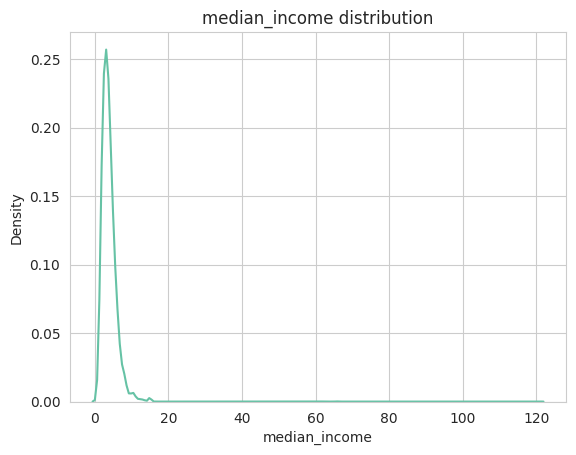

In [627]:
plot_dist(df_califonia,"median_income")

*The  median_income col has positive skewnes with a bunch of outliers that affect the mean hence we use median to fill in missing values*

In [628]:
# fill in missing values with median
df_califonia["median_income"] = df_califonia["median_income"].fillna(df_califonia["median_income"].median())

In [629]:
# recheck for missing values 
missing(df_califonia,"median_income")

 we have 0.0 % from median_income


Total bedrooms

In [630]:
missing(df_califonia,"total_bedrooms")

 we have 10.014499758337362 % from total_bedrooms we can go ahead and fill in the missing values


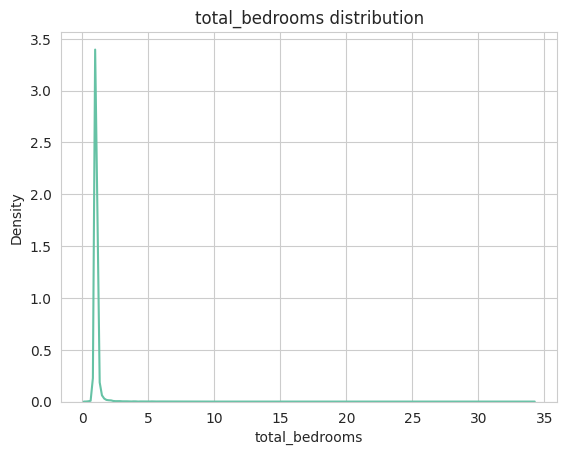

In [631]:
plot_dist(df_califonia,"total_bedrooms")

Data is skewed  we use median 

In [632]:
# fill in missing values
df_califonia["total_bedrooms"] = df_califonia["total_bedrooms"].fillna(df_califonia["total_bedrooms"].median())

In [633]:
# recheck  missing values 
missing(df_califonia,"total_bedrooms")

 we have 0.0 % from total_bedrooms


ocean_proximity

In [634]:
missing(df_califonia,"ocean_proximity")

 we have 0.49782503624939584 % from ocean_proximity we can go ahead and fill in the missing values


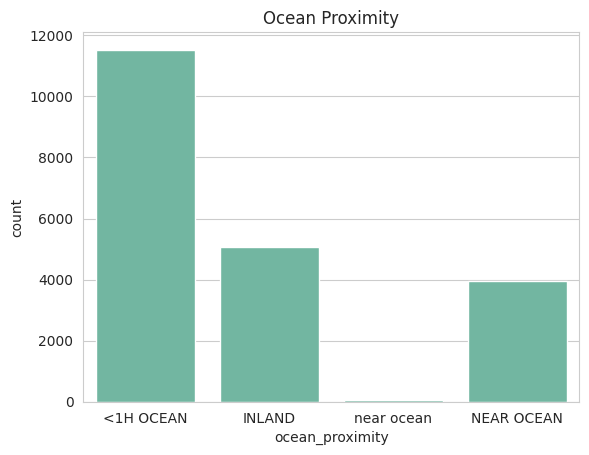

In [635]:
fig,ax = plt.subplots()
sns.countplot(data=df_califonia,x="ocean_proximity",ax=ax)
ax.set_title("Ocean Proximity")
plt.show()

value is categroical fill with mode 

In [636]:
# fill in with mode 
df_califonia["ocean_proximity"] = df_califonia["ocean_proximity"].fillna(df_califonia["ocean_proximity"].mode()[0])

In [637]:
missing(df_califonia,"ocean_proximity")

 we have 0.0 % from ocean_proximity


In [638]:
print(df_califonia.isna().sum())
print("Clean data no missing values")

median_income         0
HouseAge              0
total_rooms           0
total_bedrooms        0
population            0
households            0
latitude              0
longitude             0
median_house_value    0
ocean_proximity       0
dtype: int64
Clean data no missing values


# Detect Outliers

In [639]:
def plot_all_boxplots(df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    n = len(numeric_cols)
    
    n_rows = 2
    n_cols = math.ceil(n / n_rows)  # columns per row
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
    
    # Flatten axes array for easy indexing
    axes = axes.flatten()
    
    for i, col in enumerate(numeric_cols):
        sns.boxplot(data=df, x=col, ax=axes[i], orient='h')
        axes[i].set_title(f"{col} boxplot")
    
    # Hide any empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

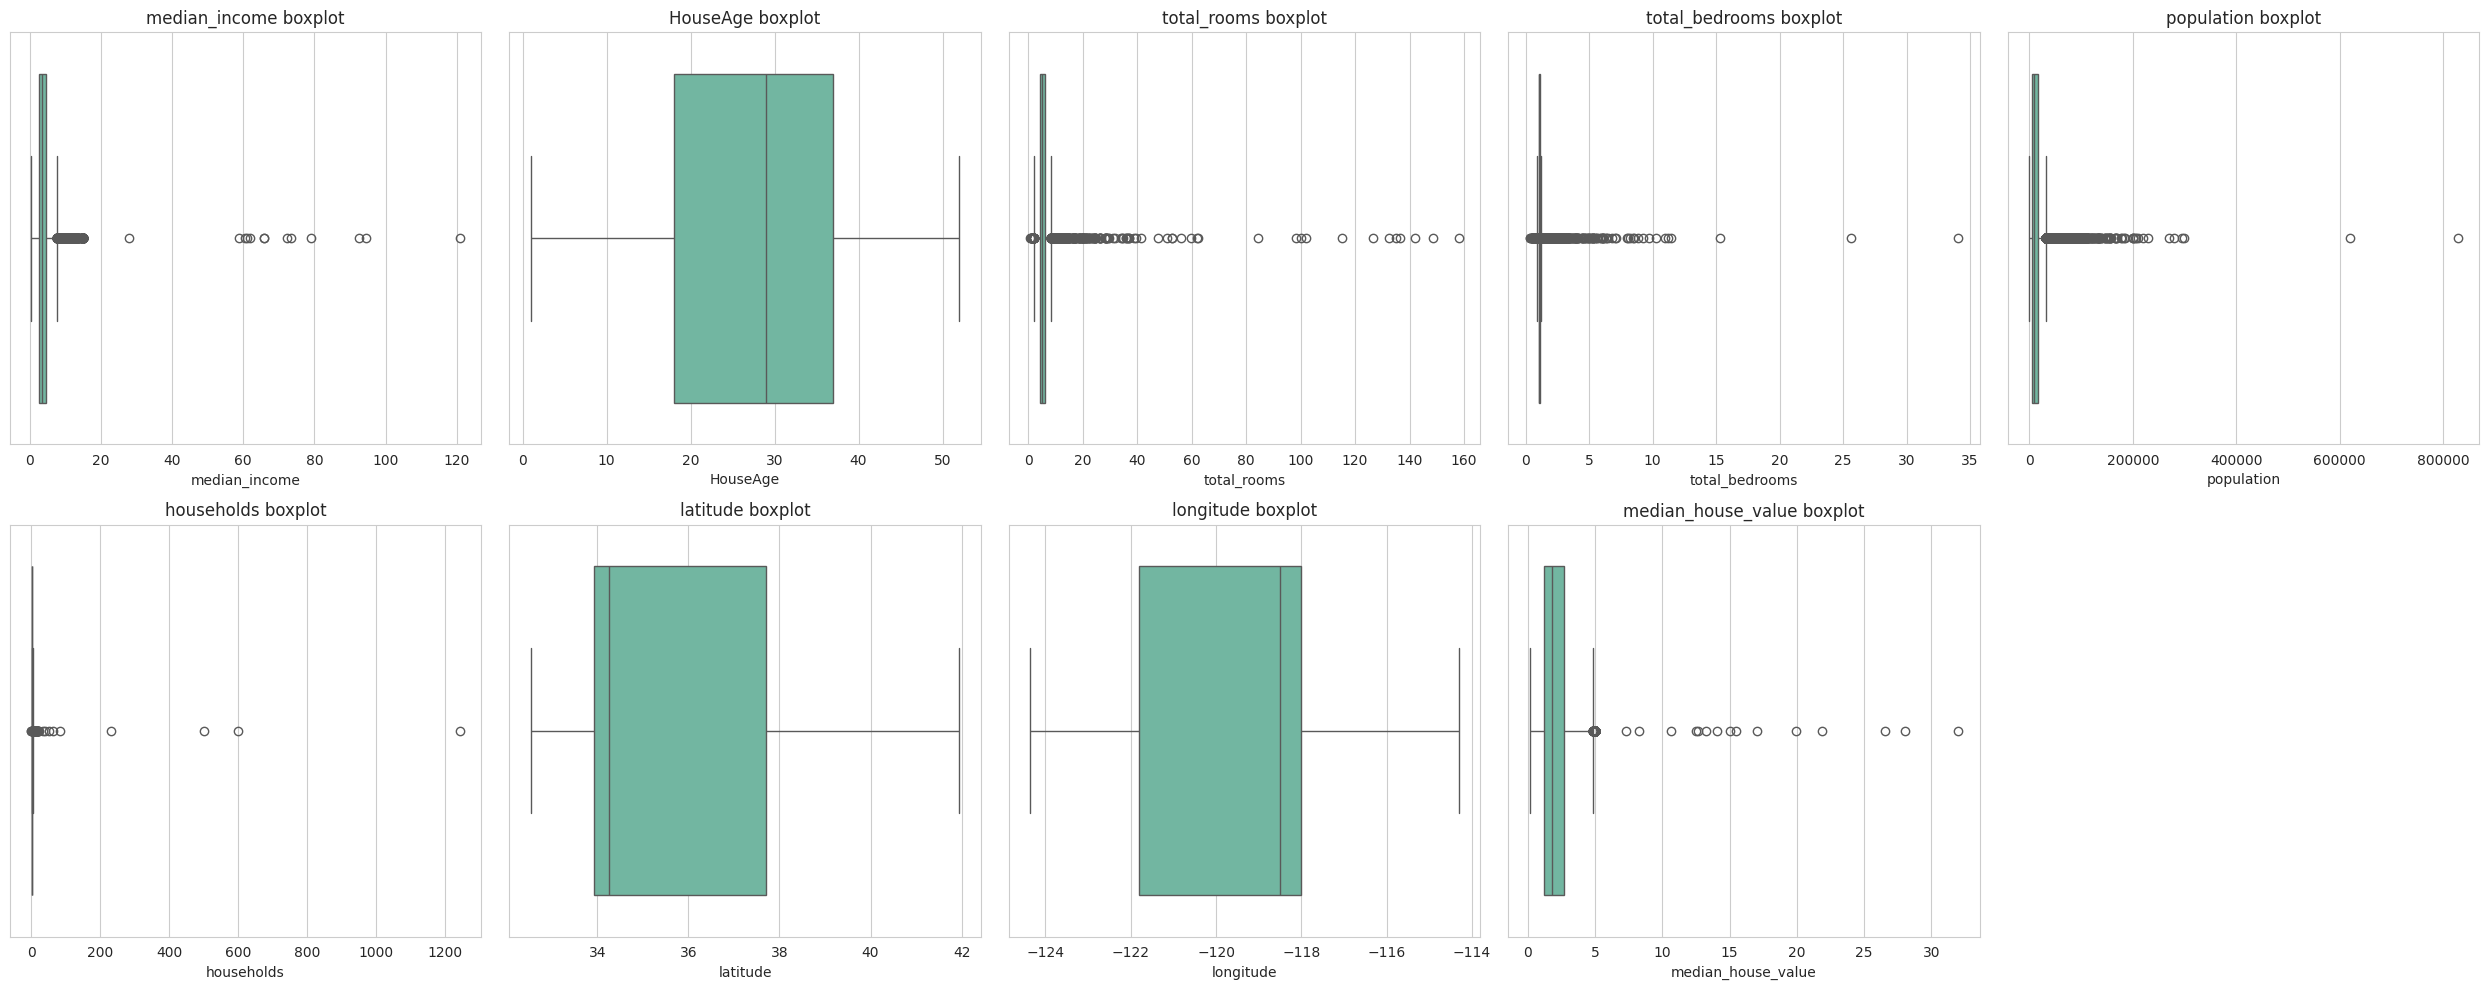

In [640]:
plot_all_boxplots(df_califonia)

In [641]:
def detect_outliers(df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_percentage = (len(outliers) / len(df)) * 100
        
        if outlier_percentage == 0:
            print(f"{col}: No outliers detected.")
        elif outlier_percentage < 5:
            print(f"{col}: {outlier_percentage:.2f}% outliers detected — can likely be kept.")
        elif outlier_percentage < 15:
            print(f"{col}: {outlier_percentage:.2f}% outliers detected — consider capping.")
        else:
            print(f"{col}: {outlier_percentage:.2f}% outliers detected — investigate before modeling.")

In [642]:
detect_outliers(df_califonia)

median_income: 3.75% outliers detected — can likely be kept.
HouseAge: No outliers detected.
total_rooms: 2.52% outliers detected — can likely be kept.
total_bedrooms: 7.63% outliers detected — consider capping.
population: 7.25% outliers detected — consider capping.
households: 3.45% outliers detected — can likely be kept.
latitude: No outliers detected.
longitude: No outliers detected.
median_house_value: 5.24% outliers detected — consider capping.


In [643]:
# Cap outliers 
def cap_outliers(df, cols=None):
   
    df_capped = df.copy()
    
    if cols is None:
        cols = df_capped.select_dtypes(include=[np.number]).columns
    
    for col in cols:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Cap values below lower bound
        df_capped[col] = np.where(df_capped[col] < lower_bound, lower_bound, df_capped[col])
        # Cap values above upper bound
        df_capped[col] = np.where(df_capped[col] > upper_bound, upper_bound, df_capped[col])
        
        print(f"{col}: values capped at {lower_bound:.2f} (lower) and {upper_bound:.2f} (upper)")
    
    return df_capped
    

In [644]:
# cap
df_califonia = cap_outliers(df_califonia)

median_income: values capped at -0.48 (lower) and 7.75 (upper)
HouseAge: values capped at -10.50 (lower) and 65.50 (upper)
total_rooms: values capped at 2.02 (lower) and 8.47 (upper)
total_bedrooms: values capped at 0.89 (lower) and 1.21 (upper)
population: values capped at -9666.67 (lower) and 31599.93 (upper)
households: values capped at 1.15 (lower) and 4.56 (upper)
latitude: values capped at 28.26 (lower) and 43.38 (upper)
longitude: values capped at -127.48 (lower) and -112.33 (upper)
median_house_value: values capped at -0.99 (lower) and 4.83 (upper)


In [645]:
# recheck outliers
print(detect_outliers(df_califonia))
print("Clean Data no Outliers")

median_income: No outliers detected.
HouseAge: No outliers detected.
total_rooms: No outliers detected.
total_bedrooms: No outliers detected.
population: No outliers detected.
households: No outliers detected.
latitude: No outliers detected.
longitude: No outliers detected.
median_house_value: No outliers detected.
None
Clean Data no Outliers


# EDA 

### Features with the highest coleration to price 

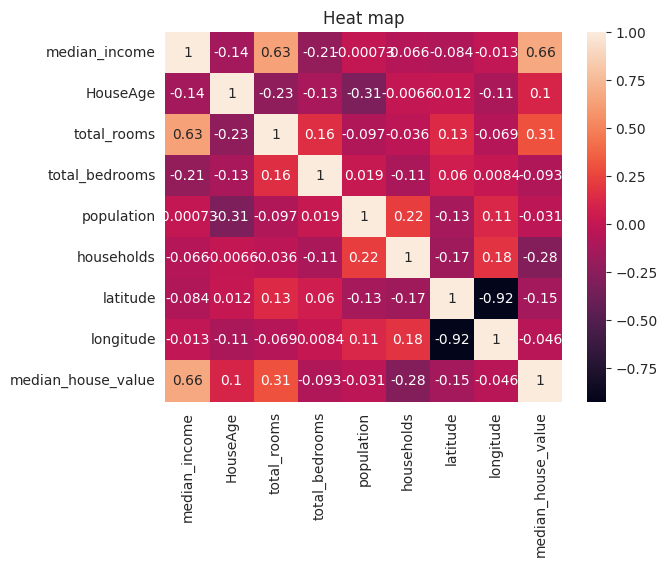

In [646]:
fig,ax = plt.subplots()
ax.set_title("Heat map")
sns.heatmap(df_califonia.select_dtypes(np.number).corr(),annot=True)

plt.show()

In [647]:
# Get correlation of all numeric features with median_house_value
price_corr = df_califonia.select_dtypes(np.number).corr()['median_house_value'].sort_values(ascending=False)
price_corr

median_house_value    1.000000
median_income         0.663884
total_rooms           0.308050
HouseAge              0.103785
population           -0.031349
longitude            -0.045640
total_bedrooms       -0.092649
latitude             -0.145780
households           -0.280825
Name: median_house_value, dtype: float64

## insights

**`median_income: 0.664`**  
   - Shows a **strong positive correlation** with house prices.  
   - Higher-income districts tend to have **higher median house values**.
   
**`total_rooms: 0.308`**  
   - Moderate positive correlation.  
   - Areas with more rooms generally have higher house prices, though the effect is not as strong as income.


## Median icome VS house value 

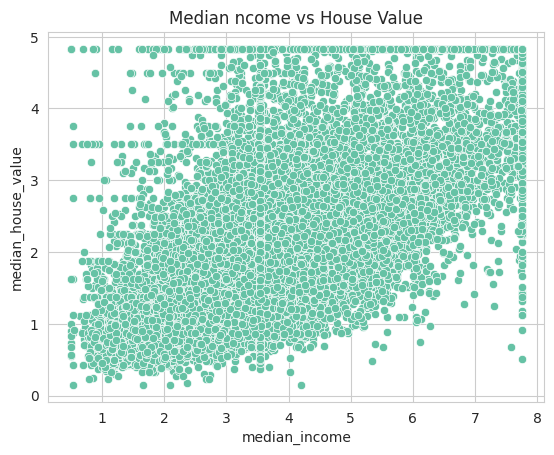

In [648]:
fig,ax = plt.subplots()
ax.set_title("Median ncome vs House Value")
sns.scatterplot(data=df_califonia,x="median_income",y="median_house_value",ax=ax)
plt.show()

### Observations from Median Income vs. Median House Value Plot

1. **Positive Relationship**  
   The plot shows a clear upward trend, meaning that as median income increases, median house value also tends to increase.  
   This visually confirms the strong positive correlation (~0.66) observed earlier.

2. **Clustering at Certain Levels**  
   Many points appear stacked horizontally or vertically, especially around specific median house values (like 0.5, 1, 2, …).  
   This is likely due to capping or rounding in the dataset, which is common in the California Housing dataset for privacy reasons.

3. **Spread of Values**  
   - Lower-income areas (median_income < 2–3) show a wide variation in house values, ranging from very low to moderately high.  
   - Higher-income areas (median_income > 6) mostly have higher house values, but there are fewer data points here, reflecting real-world distributions (fewer very high-income districts).

4. **Implications**  
   - Income is a strong predictor of house price: higher median income almost always corresponds to higher median house value.  
   - There is more variability at lower income levels, suggesting that other factors (like number of rooms, location, or population density) may influence house prices more in lower-income districts.

## Proximity to Ocean vs Price 

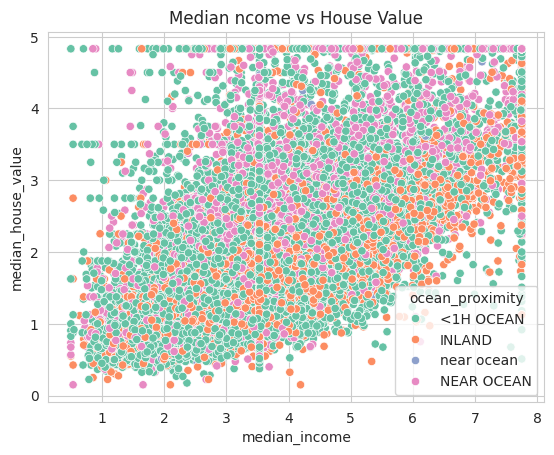

In [649]:
fig,ax = plt.subplots()
ax.set_title("Median ncome vs House Value")
sns.scatterplot(data=df_califonia,x="median_income",y="median_house_value",ax=ax,hue="ocean_proximity")
plt.show()

## Impact of Ocean Proximity

The coloring reveals how location influences the "entry price" of a home:

    Inland (Orange): These points are heavily concentrated in the lower-left quadrant. This suggests that Inland areas generally have lower median incomes and significantly lower house values compared to coastal areas.

    Coastal Categories (Blue/Red/Green): Properties labeled <1H OCEAN, NEAR OCEAN, and near ocean are spread much higher up the y-axis. Even at moderate income levels, these coastal properties tend to maintain higher values than their inland counterparts.